# Лабораторная работа №3
## Анализ ЭЭГ-сигнала во время приступа

---

**Выполнил:** *Ли Юй*  
**Группа:** *ИУ1И-41М*   

---


---
## Раздел 1. Импорт библиотек

In [6]:
from pathlib import Path
import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
import pywt

from scipy.signal import butter, filtfilt, spectrogram

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='Set2')

print('Библиотеки успешно импортированы.')

Библиотеки успешно импортированы.


---
## Раздел 2. Загрузка ЭЭГ и аннотаций датасета

В датасете Zenodo для каждого файла EDF есть три независимых файла аннотаций: `annotations_2017_A.csv`, `annotations_2017_B.csv`, `annotations_2017_C.csv`. Чтобы снизить влияние субъективности эксперта, далее используется **консенсусная разметка большинства голосов**: считаем, что в секунде есть приступ, если хотя бы 2 из 3 экспертов поставили метку `1`.

In [7]:
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'eeg1.edf').exists():
    NOTEBOOK_DIR = Path.cwd() / 'lab3'

DATA_PATH = NOTEBOOK_DIR / 'eeg1.edf'
OUT_DIR = DATA_PATH.parent
ANNOTATION_URLS = {
    'A': 'https://zenodo.org/records/2547147/files/annotations_2017_A.csv',
    'B': 'https://zenodo.org/records/2547147/files/annotations_2017_B.csv',
    'C': 'https://zenodo.org/records/2547147/files/annotations_2017_C.csv',
}

raw = mne.io.read_raw_edf(DATA_PATH, preload=True, verbose=False)
sfreq = raw.info['sfreq']
duration_sec = int(np.floor(raw.times[-1])) + 1

eeg_channels = [ch for ch in raw.ch_names if ch.startswith('EEG ')]
eeg_data = raw.copy().pick(eeg_channels).get_data()
avg_signal = eeg_data.mean(axis=0)

def load_annotation_vector(url: str, eeg_index: int = 0, max_seconds: int | None = None) -> np.ndarray:
    with urllib.request.urlopen(url, timeout=60) as response:
        lines = response.read().decode('utf-8').strip().split('\n')
    rows = lines[1:]
    if max_seconds is not None:
        rows = rows[:max_seconds]
    return np.array([int(row.split(',')[eeg_index]) for row in rows], dtype=int)

def find_blocks(seconds: np.ndarray) -> list[tuple[int, int]]:
    blocks = []
    start = int(seconds[0])
    prev = int(seconds[0])
    for second in seconds[1:]:
        second = int(second)
        if second > prev + 1:
            blocks.append((start, prev))
            start = second
        prev = second
    blocks.append((start, prev))
    return blocks

votes = np.vstack([
    load_annotation_vector(url, eeg_index=0, max_seconds=duration_sec)
    for url in ANNOTATION_URLS.values()
])
consensus_mask = votes.sum(axis=0) >= 2
seizure_seconds = np.where(consensus_mask)[0] + 1
seizure_blocks = find_blocks(seizure_seconds)

records = []
for onset_sec, end_sec in seizure_blocks:
    onset_sample = int(onset_sec * sfreq)
    end_sample = int(end_sec * sfreq)
    block_signal = avg_signal[onset_sample:end_sample]
    records.append({
        'onset_sec': onset_sec,
        'end_sec': end_sec,
        'duration_sec': end_sec - onset_sec + 1,
        'std': float(np.std(block_signal)),
        'peak_abs': float(np.max(np.abs(block_signal))),
    })

seizure_df = pd.DataFrame(records).sort_values(['peak_abs', 'duration_sec'], ascending=[False, False]).reset_index(drop=True)
selected = seizure_df.iloc[0]
selected_block_start = int(selected['onset_sec'])
selected_block_end = int(selected['end_sec'])
selected_block_duration = int(selected['duration_sec'])

plot_duration_sec = min(30, selected_block_duration)
plot_start_sec = selected_block_start + max(0, (selected_block_duration - plot_duration_sec) // 2)
plot_end_sec = plot_start_sec + plot_duration_sec

plot_slice = slice(int(plot_start_sec * sfreq), int(plot_end_sec * sfreq))
plot_time = np.arange(plot_slice.start, plot_slice.stop) / sfreq
plot_signal = avg_signal[plot_slice]

def lowpass_filter(signal: np.ndarray, cutoff_hz: float, fs: float, order: int = 5) -> np.ndarray:
    nyquist = 0.5 * fs
    b, a = butter(order, cutoff_hz / nyquist, btype='low')
    return filtfilt(b, a, signal)

avg_signal_lp60 = lowpass_filter(avg_signal, cutoff_hz=60, fs=sfreq, order=5)
plot_signal_lp60 = avg_signal_lp60[plot_slice]

print(f'Файл: {DATA_PATH.name}')
print(f'Частота дискретизации: {sfreq:.1f} Гц')
print(f'Длительность записи: {raw.times[-1] / 60:.1f} мин')
print(f'ЭЭГ-каналов для усреднения: {len(eeg_channels)}')
print(f'Всего секунд с приступом по консенсусной аннотации: {consensus_mask.sum()}')
print(f'Выбранный приступ: {selected_block_start}-{selected_block_end} c ({selected_block_duration} c)')
print(f'Фрагмент для наглядной визуализации: {plot_start_sec}-{plot_end_sec} c')

display(seizure_df.head(10).round(6))

Файл: eeg1.edf
Частота дискретизации: 256.0 Гц
Длительность записи: 116.5 мин
ЭЭГ-каналов для усреднения: 19
Всего секунд с приступом по консенсусной аннотации: 1543
Выбранный приступ: 3993-4108 c (116 c)
Фрагмент для наглядной визуализации: 4036-4066 c


,onset_sec,end_sec,duration_sec,std,peak_abs
0,3993,4108,116,0.000016,0.000308
1,317,448,132,0.000009,0.000225
2,2849,2871,23,0.000031,0.000170
3,6109,6336,228,0.000013,0.000162
4,4962,5025,64,0.000013,0.000145
5,6847,6863,17,0.000024,0.000144
6,1594,1642,49,0.000014,0.000141
7,5141,5269,129,0.000016,0.000140
8,1651,1703,53,0.000011,0.000124
9,6604,6703,100,0.000012,0.000110


---
## Раздел 3. Временная зависимость ЭЭГ в момент приступа

Из всех консенсусно размеченных эпизодов выбран приступ с наибольшей пиковой амплитудой в усреднённом сигнале. Это даёт наиболее наглядный фрагмент для визуального анализа. Ниже показаны:
- усреднённый сигнал по всем ЭЭГ-каналам
- тот же сигнал после удаления частот выше 60 Гц

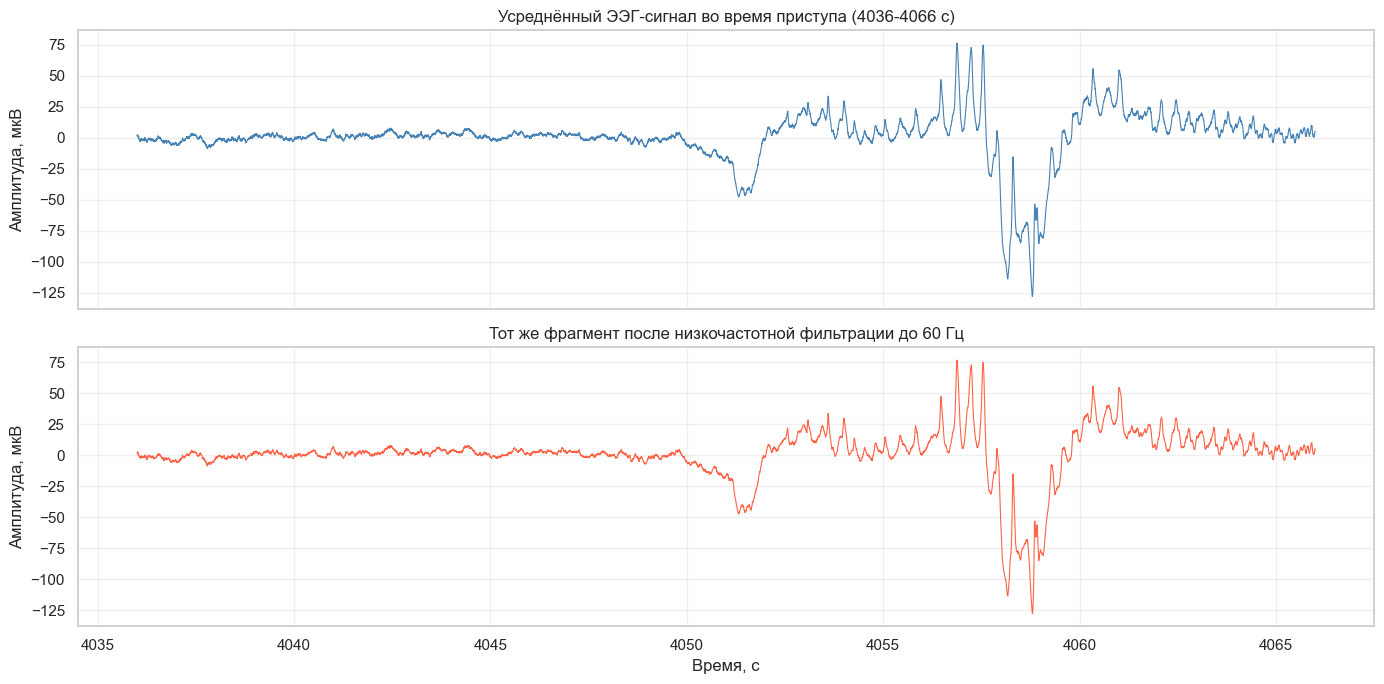

График сохранён в seizure_time_plot.png


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(plot_time, plot_signal * 1e6, color='steelblue', linewidth=0.8)
axes[0].set_title(
    f'Усреднённый ЭЭГ-сигнал во время приступа ({plot_start_sec}-{plot_end_sec} c)',
    fontsize=12
)
axes[0].set_ylabel('Амплитуда, мкВ')
axes[0].grid(alpha=0.3)

axes[1].plot(plot_time, plot_signal_lp60 * 1e6, color='tomato', linewidth=0.8)
axes[1].set_title('Тот же фрагмент после низкочастотной фильтрации до 60 Гц', fontsize=12)
axes[1].set_xlabel('Время, с')
axes[1].set_ylabel('Амплитуда, мкВ')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'seizure_time_plot.png', dpi=120, bbox_inches='tight')
plt.show()

print('График сохранён в seizure_time_plot.png')

---
## Раздел 4. Спектрограмма отфильтрованного сигнала

Спектрограмма строится для усреднённого и отфильтрованного сигнала на выбранном фрагменте приступа. Ограничение по частоте сверху равно 60 Гц, поэтому дальнейший анализ выполняется только в диапазоне от 0 до 60 Гц.

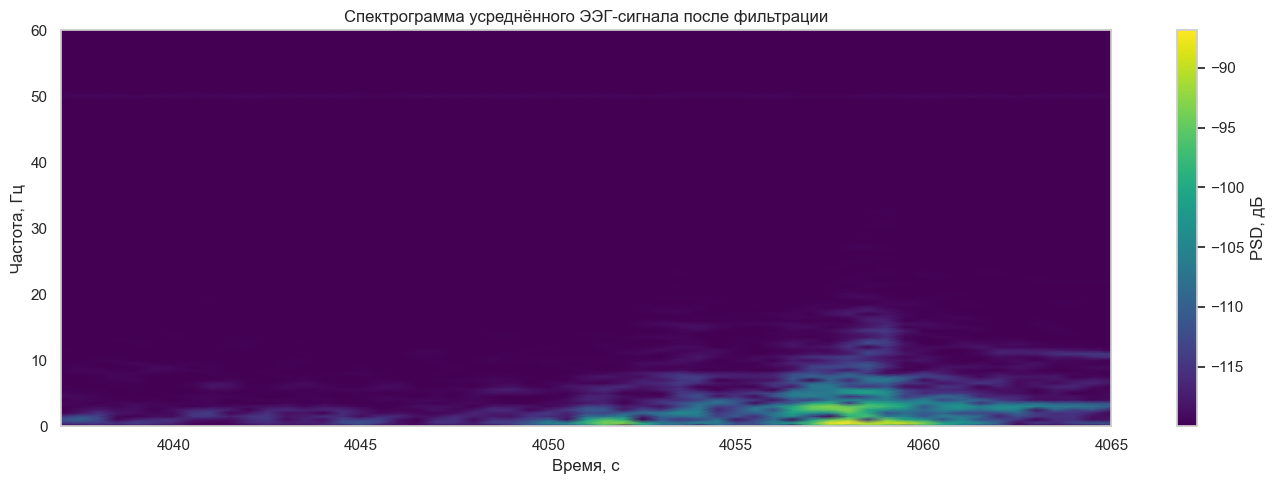

Спектрограмма сохранена в spectrogram_lp60.png


In [9]:
frequencies, times_spec, spec_power = spectrogram(
    plot_signal_lp60,
    fs=sfreq,
    window='hann',
    nperseg=512,
    noverlap=384,
    scaling='density',
    mode='psd'
)

mask_60 = frequencies <= 60
frequencies = frequencies[mask_60]
spec_power = spec_power[mask_60]
spec_power_db = 10 * np.log10(spec_power + 1e-12)

fig, ax = plt.subplots(figsize=(14, 5))
mesh = ax.pcolormesh(plot_start_sec + times_spec, frequencies, spec_power_db, shading='gouraud', cmap='viridis')
ax.set_title('Спектрограмма усреднённого ЭЭГ-сигнала после фильтрации', fontsize=12)
ax.set_xlabel('Время, с')
ax.set_ylabel('Частота, Гц')
ax.set_ylim(0, 60)
fig.colorbar(mesh, ax=ax, label='PSD, дБ')
plt.tight_layout()
plt.savefig(OUT_DIR / 'spectrogram_lp60.png', dpi=120, bbox_inches='tight')
plt.show()

print('Спектрограмма сохранена в spectrogram_lp60.png')

---
## Раздел 5. Вейвлет-преобразование (скейлограмма)

Для скейлограммы используется непрерывное вейвлет-преобразование Морле (`morl`). Оно позволяет увидеть, как энергетика сигнала распределяется одновременно по времени и частоте, и лучше подчёркивает кратковременные изменения, характерные для приступа.

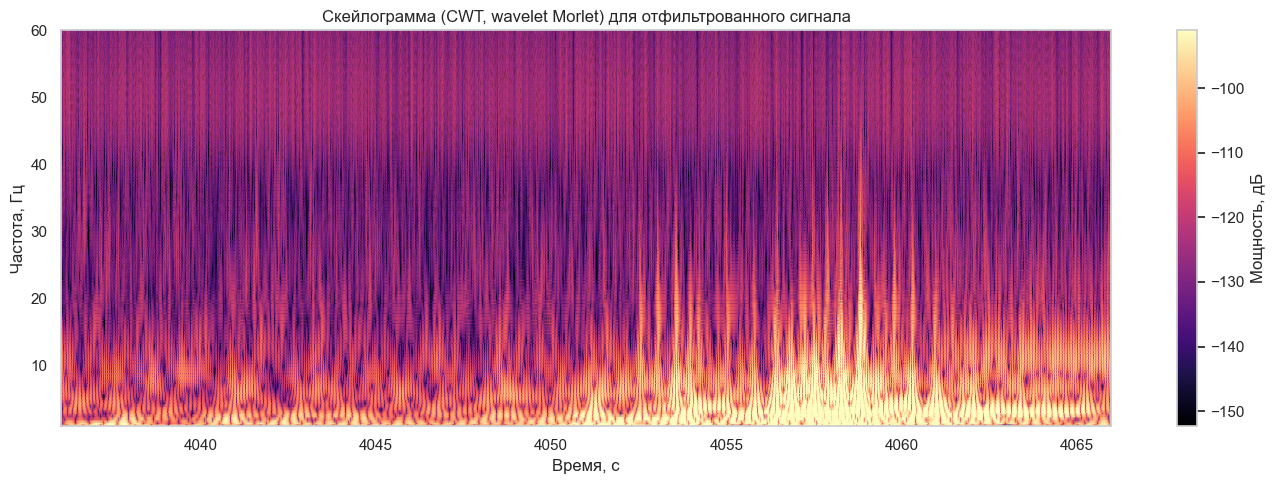

Скейлограмма сохранена в wavelet_scalogram.png


In [12]:
wavelet_name = 'morl'
wavelet_freqs = np.linspace(1, 60, 120)
scales = pywt.central_frequency(wavelet_name) * sfreq / wavelet_freqs
coefficients, cwt_freqs = pywt.cwt(
    plot_signal_lp60,
    scales,
    wavelet_name,
    sampling_period=1 / sfreq
)

order = np.argsort(cwt_freqs)
cwt_freqs = cwt_freqs[order]
wavelet_power = 10 * np.log10(np.abs(coefficients[order]) ** 2 + 1e-30)

vmin, vmax = np.percentile(wavelet_power, [2, 98])

fig, ax = plt.subplots(figsize=(14, 5))
mesh = ax.pcolormesh(plot_time, cwt_freqs, wavelet_power, shading='gouraud', cmap='magma', vmin=vmin, vmax=vmax)
ax.set_title('Скейлограмма (CWT, wavelet Morlet) для отфильтрованного сигнала', fontsize=12)
ax.set_xlabel('Время, с')
ax.set_ylabel('Частота, Гц')
ax.set_ylim(1, 60)
fig.colorbar(mesh, ax=ax, label='Мощность, дБ')
plt.tight_layout()
plt.savefig(OUT_DIR / 'wavelet_scalogram.png', dpi=120, bbox_inches='tight')
plt.show()

print('Скейлограмма сохранена в wavelet_scalogram.png')

---
## Общий вывод по лабораторной работе

В данной работе был проанализирован файл `eeg1.edf` из датасета Zenodo с неонатальной ЭЭГ. Поскольку внутри EDF-файла встроенных аннотаций нет, приступ был определён по внешним файлам аннотаций датасета. Для повышения надёжности использовалась консенсусная разметка по трём экспертам.

### 1. Определение приступа

По консенсусной аннотации в записи обнаружено несколько эпизодов приступной активности. Для детального анализа был выбран эпизод с наибольшей пиковой амплитудой в усреднённом сигнале: **3993–4108 с**. Для наглядного графика использован центральный 30-секундный фрагмент этого эпизода.

### 2. Усреднение каналов и фильтрация

Все ЭЭГ-каналы были усреднены в один сигнал по формуле среднего арифметического. Затем к полученному сигналу был применён low-pass фильтр с частотой среза 60 Гц, что позволило убрать высокочастотные компоненты и сделать структуру приступа более читаемой.

### 3. Спектральный и вейвлет-анализ

- **Спектрограмма** показала, как распределение энергии меняется во времени в диапазоне до 60 Гц.
- **Скейлограмма** дала более детальную временно-частотную картину и позволила увидеть локальные изменения мощности во время приступа.

> **Главный вывод:** усреднение по каналам вместе с фильтрацией и временно-частотным анализом позволяет компактно и наглядно исследовать структуру приступной активности в ЭЭГ. Для нестационарных сигналов, таких как ЭЭГ, вейвлет-преобразование особенно полезно, потому что лучше локализует кратковременные изменения, чем классический спектральный анализ.